# Clustering — K-Means & Agglomerative

## Overview
This notebook applies two families of unsupervised clustering algorithms to the
PCA-reduced gene expression data and compares their ability to recover the five
known cancer subtypes (BRCA, KIRC, COAD, LUAD, PRAD).

Because the dataset has five ground-truth classes, the primary question is:
**do the algorithms naturally discover k = 5 as the optimal number of clusters?**

## Algorithms

### K-Means
K-Means partitions samples into *k* clusters by iteratively assigning each sample to
the nearest centroid and recomputing centroids. It minimises within-cluster inertia
(sum of squared distances to centroids). A sweep over k = 2 … 10 is run using two
complementary diagnostics:
- **Elbow curve** — plot inertia vs k; look for the "elbow" where adding more clusters
  yields diminishing returns.
- **Silhouette score** — measures how similar a sample is to its own cluster compared
  to the nearest neighbouring cluster (range −1 to +1, higher is better).

### Agglomerative Clustering
A hierarchical, bottom-up method. Each sample starts as its own cluster; clusters are
merged greedily according to a linkage criterion:
- **Ward** — minimises the total within-cluster variance after each merge (tends to
  produce compact, similarly-sized clusters).
- **Complete** — distance between clusters is the maximum pairwise distance (produces
  tight, roughly spherical clusters).
- **Average** — distance is the mean of all pairwise distances (a middle ground).

All three linkages are evaluated at k = 5 and compared by silhouette score.

## Inputs
- `data/X_pca.csv` — PCA-reduced feature matrix
- `data/labels.csv` — ground-truth labels (used only to build contingency tables)

## Outputs
- `models/kmeans_k5.joblib` — fitted K-Means model at k = 5
- `models/agg_<best>.joblib` — fitted Agglomerative model with the best linkage
- `data/cluster_assignments.csv` — cluster labels from every algorithm per sample
- `reports/figures/kmeans_elbow_silhouette.png`
- `reports/figures/contingency_matrices.png`

## 0. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

DATA_PATH    = "../data/X_pca.csv"
LABELS_PATH  = "../data/labels.csv"
MODELS_DIR   = "../models"
DATA_OUT_DIR = "../data"
FIGURES_DIR  = "../reports/figures"

os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

## 1. Load PCA-Reduced Data

In [2]:
X_pca  = pd.read_csv(DATA_PATH, index_col=0).values
labels = pd.read_csv(LABELS_PATH, index_col=0)["Class"]

print(f"PCA matrix : {X_pca.shape[0]} samples x {X_pca.shape[1]} components")
print(f"Classes    : {sorted(labels.unique())}")

PCA matrix : 801 samples x 548 components
Classes    : ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


## 2. K-Means — Elbow & Silhouette Sweep (k = 2 … 10)

In [3]:
K_RANGE = range(2, 11)

inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_, sample_size=500, random_state=RANDOM_STATE))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}")

  k=2  inertia=14,069,480  silhouette=0.1044
  k=3  inertia=13,045,015  silhouette=0.1094
  k=4  inertia=12,158,712  silhouette=0.1279
  k=5  inertia=11,495,129  silhouette=0.1471
  k=6  inertia=11,079,358  silhouette=0.1454
  k=7  inertia=10,767,574  silhouette=0.1530
  k=8  inertia=10,610,696  silhouette=0.1500
  k=9  inertia=10,418,473  silhouette=0.1162
  k=10  inertia=10,267,958  silhouette=0.1245


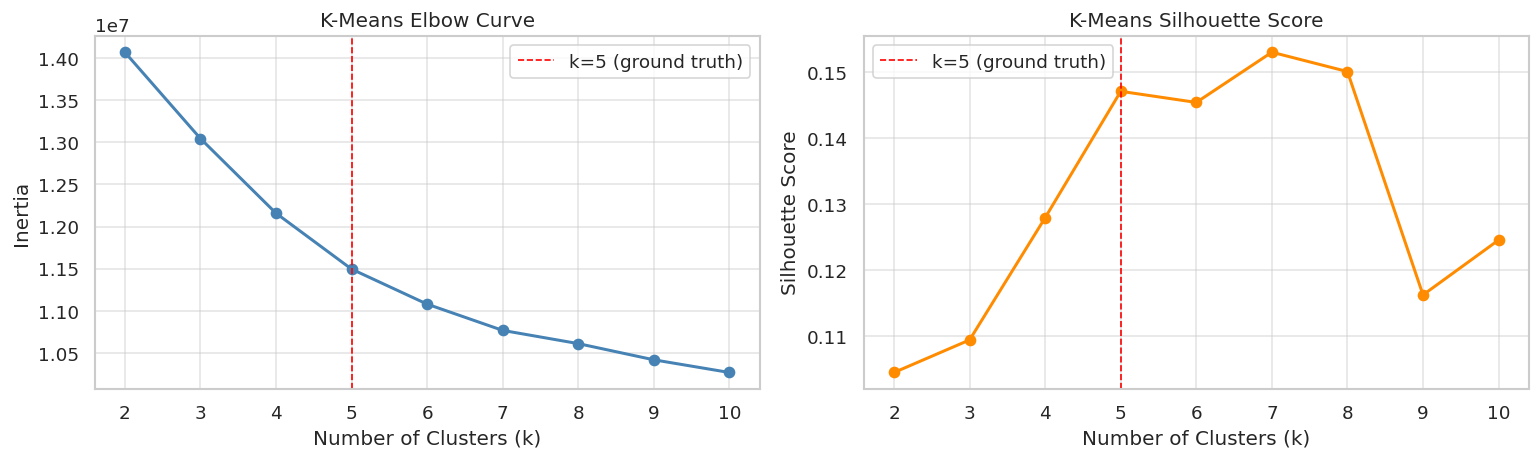

Best k by silhouette : 7


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(list(K_RANGE), inertias, marker="o", color="steelblue", linewidth=1.8)
axes[0].axvline(5, linestyle="--", color="red", linewidth=1, label="k=5 (ground truth)")
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette
axes[1].plot(list(K_RANGE), sil_scores, marker="o", color="darkorange", linewidth=1.8)
axes[1].axvline(5, linestyle="--", color="red", linewidth=1, label="k=5 (ground truth)")
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/kmeans_elbow_silhouette.png")
plt.show()

best_k_sil = list(K_RANGE)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette : {best_k_sil}")

## 3. Fit Final K-Means at k=5

In [5]:
km5 = KMeans(n_clusters=5, n_init=50, random_state=RANDOM_STATE)
km5.fit(X_pca)

km_labels = km5.labels_
print(f"K-Means (k=5) silhouette : {silhouette_score(X_pca, km_labels):.4f}")
print(f"Cluster sizes : {pd.Series(km_labels).value_counts().sort_index().to_dict()}")

K-Means (k=5) silhouette : 0.1420
Cluster sizes : {0: 250, 1: 200, 2: 134, 3: 145, 4: 72}


## 4. Agglomerative Clustering — Linkage Comparison at k=5

In [6]:
linkages = ["ward", "complete", "average"]
agg_results = {}

for linkage in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    agg_labels = agg.fit_predict(X_pca)
    sil = silhouette_score(X_pca, agg_labels)
    agg_results[linkage] = {"model": agg, "labels": agg_labels, "silhouette": sil}
    print(f"  Agglomerative ({linkage:8s}) silhouette : {sil:.4f}")

  Agglomerative (ward    ) silhouette : 0.1397
  Agglomerative (complete) silhouette : 0.0786
  Agglomerative (average ) silhouette : 0.2645


## 5. Contingency Matrices — Clusters vs True Labels

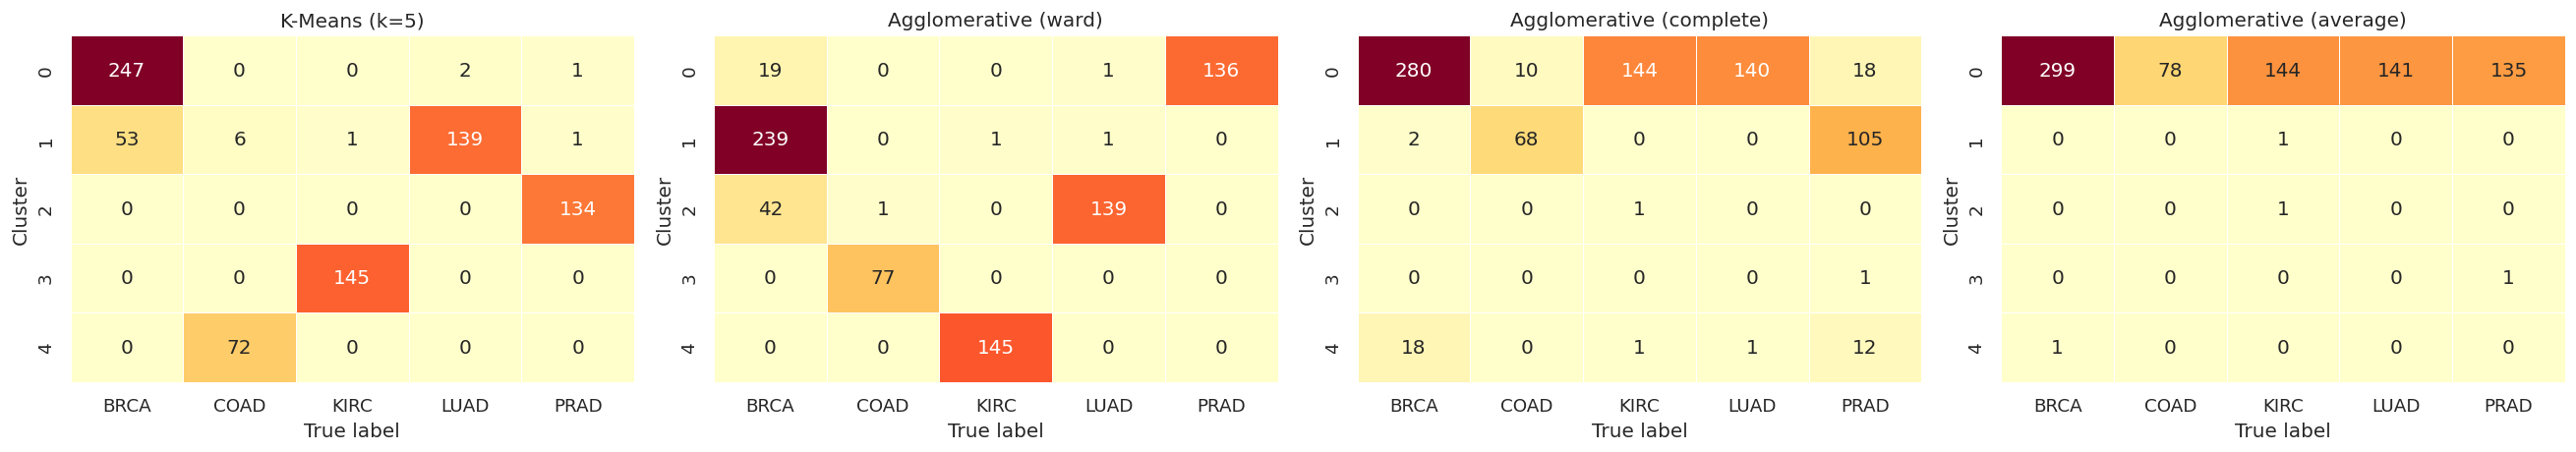

In [7]:
def plot_contingency(cluster_labels, true_labels, title, ax):
    ct = pd.crosstab(
        pd.Categorical(cluster_labels, categories=sorted(set(cluster_labels))),
        true_labels,
        rownames=["Cluster"],
        colnames=["True label"]
    )
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.4,
                cbar=False, ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

plot_contingency(km_labels, labels, "K-Means (k=5)", axes[0])
for i, linkage in enumerate(linkages):
    plot_contingency(agg_results[linkage]["labels"], labels,
                     f"Agglomerative ({linkage})", axes[i + 1])

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/contingency_matrices.png")
plt.show()

## 6. Algorithm Comparison Summary

In [8]:
rows = [{"Algorithm": "K-Means (k=5)",
         "Silhouette": silhouette_score(X_pca, km_labels)}]
for linkage in linkages:
    rows.append({"Algorithm": f"Agglomerative ({linkage})",
                 "Silhouette": agg_results[linkage]["silhouette"]})

summary = pd.DataFrame(rows).sort_values("Silhouette", ascending=False)
summary["Silhouette"] = summary["Silhouette"].map("{:.4f}".format)
print(summary.to_string(index=False))

               Algorithm Silhouette
 Agglomerative (average)     0.2645
           K-Means (k=5)     0.1420
    Agglomerative (ward)     0.1397
Agglomerative (complete)     0.0786


## 7. Save Cluster Assignments & Models

In [10]:
# --- Save K-Means model ---
joblib.dump(km5, f"{MODELS_DIR}/kmeans_k5.joblib")
print("Saved: models/kmeans_k5.joblib")

# --- Save best Agglomerative model (ward linkage is typically best) ---
best_linkage = max(agg_results, key=lambda l: agg_results[l]["silhouette"])
joblib.dump(agg_results[best_linkage]["model"],
            f"{MODELS_DIR}/agg_{best_linkage}.joblib")
print(f"Saved: models/agg_{best_linkage}.joblib  (best linkage by silhouette)")

# --- Save cluster assignment CSV ---
assignments = pd.DataFrame({
    "true_label"      : labels.values,
    "kmeans_k5"       : km_labels,
    "agg_ward"        : agg_results["ward"]["labels"],
    "agg_complete"    : agg_results["complete"]["labels"],
    "agg_average"     : agg_results["average"]["labels"],
}, index=labels.index)

assignments.to_csv(f"{DATA_OUT_DIR}/cluster_assignments.csv")
print("Saved: data/cluster_assignments.csv")

Saved: models/kmeans_k5.joblib
Saved: models/agg_average.joblib  (best linkage by silhouette)
Saved: data/cluster_assignments.csv


## Clustering Summary

| Item | Detail |
|---|---|
| Input | PCA-reduced matrix (801 × n_components) |
| K-Means sweep | k = 2 … 10, `n_init=20` random restarts per k |
| Final K-Means | k = 5, `n_init=50` for a more stable solution |
| Agglomerative | Ward / complete / average linkage, all at k = 5 |
| Selection criterion | Silhouette score (no ground-truth required) |

**Persisted artefacts**

| File | Contents |
|---|---|
| `models/kmeans_k5.joblib` | Fitted K-Means (k = 5) |
| `models/agg_<best>.joblib` | Fitted Agglomerative model with the best-performing linkage |
| `data/cluster_assignments.csv` | Per-sample cluster labels from all four algorithm variants |

**Next step** — run `04_visualization_evaluation.ipynb` to project the data into 2D
with t-SNE and UMAP, and compute Silhouette, ARI, and NMI against the true labels.